<a href="https://colab.research.google.com/github/rifkiabdulaziz-lab/analis_sistem_PosAja/blob/main/Copy_of_uts_aplikasi_pos_aja_rifki_abdul_aziz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google-play-scraper

In [ ]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.posindonesia.cob',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 1000 ulasan ke 'ulasan_google_play.csv'


In [ ]:
import pandas as pd
from transformers import pipeline

# Muat data dari file CSV yang sudah dibuat sebelumnya
df = pd.read_csv('/content/ulasan_google_play.csv')

# Inisialisasi pipeline sentiment analysis dengan model Indo-RoBERTa
# Model ini mengklasifikasikan teks ke dalam 3 label: Positive, Neutral, Negative
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

def get_sentiment(text):
    try:
        # Batasi teks agar tidak melebihi kapasitas model (biasanya 512 token)
        result = sentiment_pipeline(str(text)[:512])[0]
        return result['label'], result['score']
    except:
        return "Error", 0.0

# Jalankan analisis (ini mungkin memakan waktu beberapa menit tergantung jumlah data)
print("Sedang memproses sentimen...")
df[['label', 'confidence']] = df['content'].apply(lambda x: pd.Series(get_sentiment(x)))

# Tampilkan hasil
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sedang memproses sentimen...


,userName,score,at,content,label,confidence
0,Soleh S,1,2026-04-29 10:23:42,"scan barcode tidak bisa bisanya di Web, itupun...",negative,0.987916
1,Ama No,1,2026-04-28 14:48:01,"jangan di download, karena ini aplikasi Sampah...",negative,0.992506
2,SAMSUL RIJAL,5,2026-04-27 03:58:46,bagai mana cara menggunakan poin yang sudah ka...,negative,0.894086
3,Uman Rukmana,1,2026-04-26 23:00:45,ribet mau cek tarif aja susah udah cape ngisi ...,negative,0.998580
4,Eko Dwi Istiyanto,1,2026-04-25 15:07:48,"Ya beginilah kwalitas BUMN di negeri ini, gima...",negative,0.997102


In [ ]:
# Ringkasan Statistik Sentimen
print("Ringkasan Sentimen:")
print(df['label'].value_counts())

# Simpan hasil analisis ke CSV baru
df.to_csv('ulasan_google_play_analyzed.csv', index=False)
print("\nHasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'")

Ringkasan Sentimen:
label
negative    565
positive    338
neutral      97
Name: count, dtype: int64

Hasil analisis disimpan ke 'ulasan_google_play_analyzed.csv'


Grafik telah disimpan sebagai 'visualisasi_sentimen.png'


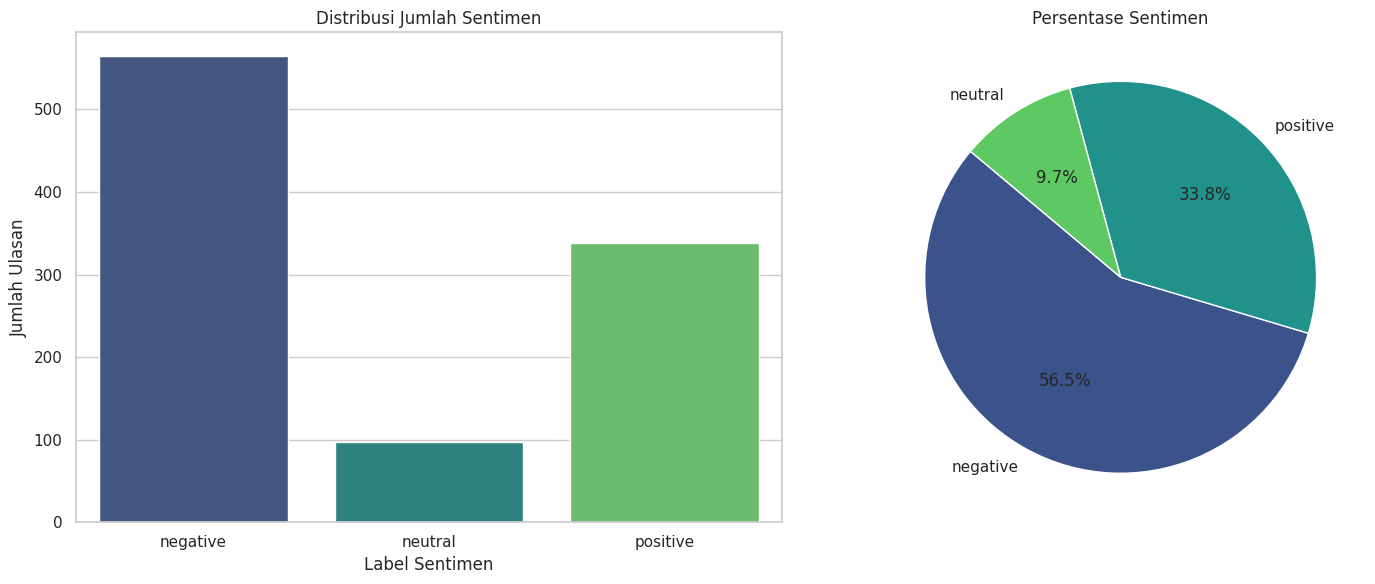

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya visualisasi
sns.set(style="whitegrid")

# Membuat figure dengan dua subplot
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart: Distribusi Jumlah Sentimen
sns.countplot(x='label', data=df, hue='label', palette='viridis', ax=ax[0], legend=False)
ax[0].set_title('Distribusi Jumlah Sentimen')
ax[0].set_xlabel('Label Sentimen')
ax[0].set_ylabel('Jumlah Ulasan')

# 2. Pie Chart: Persentase Sentimen
sentiment_counts = df['label'].value_counts()
ax[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
ax[1].set_title('Persentase Sentimen')

plt.tight_layout()

# Menyimpan grafik ke dalam file
plt.savefig('visualisasi_sentimen.png', dpi=300)
print("Grafik telah disimpan sebagai 'visualisasi_sentimen.png'")

plt.show()

In [ ]:
# Menampilkan ulasan negatif yang memiliki 20 kata atau lebih secara utuh
long_negative_reviews = df[(df['label'] == 'negative') & (df['content'].str.split().str.len() >= 20)][['userName', 'content']]

pd.set_option('display.max_colwidth', None)

# Menyimpan hasil ulasan negatif panjang ke file CSV
long_negative_reviews.to_csv('ulasan_negatif_panjang.csv', index=False)

print(f"Menampilkan {len(long_negative_reviews)} ulasan negatif mendetail:")
print(f"Daftar ini juga telah disimpan ke dalam file 'ulasan_negatif_panjang.csv'")
display(long_negative_reviews)

Menampilkan 208 ulasan negatif mendetail:
Daftar ini juga telah disimpan ke dalam file 'ulasan_negatif_panjang.csv'


,userName,content
3,Uman Rukmana,"ribet mau cek tarif aja susah udah cape ngisi semua data klik tombol cek tarif keterangan layanan yang anda pilih tidak tersedia, semua pilihan possomeday, nextdaydn reguler sama aja hasilnya nihil. Sampah swasta aja jelas"
4,Eko Dwi Istiyanto,"Ya beginilah kwalitas BUMN di negeri ini, gimana negara ga rugi terus, sekedar ngirim paket dari grobogan ke Bekasi aja udah 5 hari ga sampe, padahal kalo pake produk swasta paling 2 hari sampe, kapok-kapok"
5,fanny skylar,2 kali beli paket pengiriman pake pos lama banget stuck stuck pos pengiriman deket aja kelamaaannnnnnnnnnn g usah pada pake dah daripada nyesel apalagi kalo beli beli hewan hidup
6,Steady Flashing,"Pelayanan PoS ID yang sangat lambat, lelet, kurirnya loyo, status pesanan sudah diantarkan ,masa sih sampai 3 hari ga sampai padahal cuma satu kota, alamat tidak ditemukan lah alasan klasik"
15,Erna Dwi,"apk yang tidak rekomendasi, pernah mau kirim lewat apk, tapi kecepatan pickup lama. untuk pengembalian dana sudah by email, datang ke kantor pos. Sampai saat ini tidak ada tindaklanjut untuk pengembalian dana saya, dan saya tidak dibantu. Malah sekarang di apk oleh cs paket sudah diterima. Padahal hal tersebut saya yang mengirim sendiri,karena kecepatan kurir yang tidak memungkinkan.saya meminta pengembalian dana, sampai saat ini tidak ada tindak lanjut.kurang rekomendasi dari segi pelayanan/apk"
...,...,...
979,Mariyeh,"Siapapun tolong jangan instal App tidak berguna ini, sebab kamu hanya akan buang2 kuota dan waktu. Meski kamu install akan percuma Sistem loginnya ribet dan tidak akan berhasil. Belum juga login sudah minta perbaharui, dan pemulihan akun. Ini APP yang tidak paling berguna yang saya punya. Padahal mau cek resi paket yang sudah lama ga ada kabarnya"
988,_MAZBROW OFFICIAL,"Baru x ini pakek PosAja, paket gak jelas sudah sampe mana. Dan harga nya gak jauh beda per Kg nya Sama j&t. Saran saya pakek yang lain saja kalau mau kirim paket atau apa itu. Pelayanan lemot"
990,Firdaus Dharma22,"sistem update nya lama udah gitu eror, pengembalian dananya jga lama banget, kurang bagus buat di pake online apk nya"
994,ika prawira,Knp ya skrg resi Pos saya tdk bs d cek Dan aplikasi pos juga g menerima no otpx stlh d masukkan???
